# **Salifort Motors Employee Turnover Analysis**

## Business scenario and problem

Salifort Motors experiences a number of employee turnover (employee resigning) and they want to make initiatives on reducing it. Employee leaving costs the company huge money which is present in cost of recruitment ads, hiring process, benefits, training, and especially the experience and knowledge the employee carry. 

We are tasked to analyze the data collected by the HR department and suggest data-driven solutions.

Objectives for this project:
- Create **predictive model** that will determine whether or not an employee will leave
- Identify **features/reasons** that mostly affect the employee decision to leave

Let's divide the notebook into important parts:
1. Data Loading and Initial EDA
2. EDA with Visualizations
3. Hypothesis Testing
4. Data Modelling and Evaluation
5. Conclusion

### Data Dictionary

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

## 1. Data Loading and Initial EDA

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For saving model
import pickle

pd.set_option('display.max_columns', None)

In [2]:
# Load dataset into a dataframe
df0 = pd.read_csv("HR_capstone_dataset.csv")

# Display first few rows of the dataframe
df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [3]:
# Gather basic information about the data
df0.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


The data is composed of 14999 rows and 9 columns. The dataset is mostly numeric, only 2 columns are object which we'll encode later. The column of our main interest is `left` which tells if the employee left the company or not.

We need to standardize the naming of the columns into snake_case for a cleaner and comprehensible dataset.

In [4]:
# Rename columns as needed
df0 = df0.rename(columns={'average_montly_hours': 'average_monthly_hours',
                          'Work_accident': 'work_accident', 
                          'Department': 'department',
                          'time_spend_company': 'tenure'
                         })

# Display all column names after the update
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='str')

In [5]:
# Check for missing values
df0.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
tenure                   0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

In [6]:
# Check for duplicates
df0.duplicated().sum()

np.int64(3008)

In [7]:
# Inspect some rows containing duplicates as needed
df0[df0.duplicated()]

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


The duplicates are less likely to be at random and real cases since we have two continuous variables and several columns. We need to drop the duplicates.

In [8]:
# Drop duplicates and save resulting dataframe in a new variable as needed
df1 = df0.drop_duplicates(keep='first')

# Display first few rows of new dataframe as needed
df1.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## 2. EDA with Visualizations

### A. Univariate Analysis

We will perform a univariate analysis first to check data distributions

<Axes: xlabel='average_monthly_hours', ylabel='Count'>

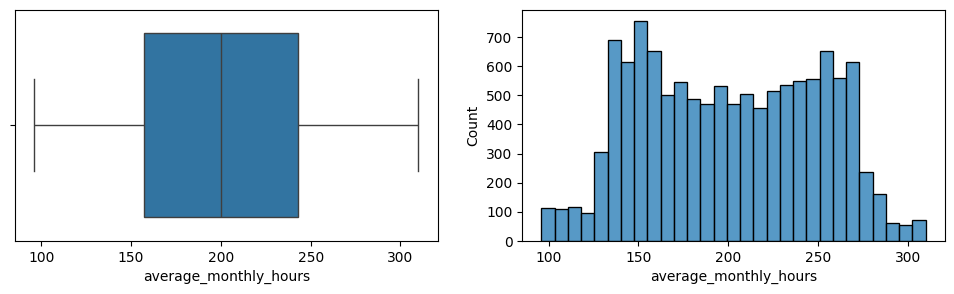

In [9]:
# Average monthly hours
fig, ax = plt.subplots(1, 2, figsize=(12, 3))
sns.boxplot(x=df1['average_monthly_hours'], ax=ax[0])
sns.histplot(x=df1['average_monthly_hours'], ax=ax[1])

No outliers observable for average_monthly_hours histplot. Most of the distribution is between 125 hours - 275 hours.

<Axes: xlabel='tenure', ylabel='Count'>

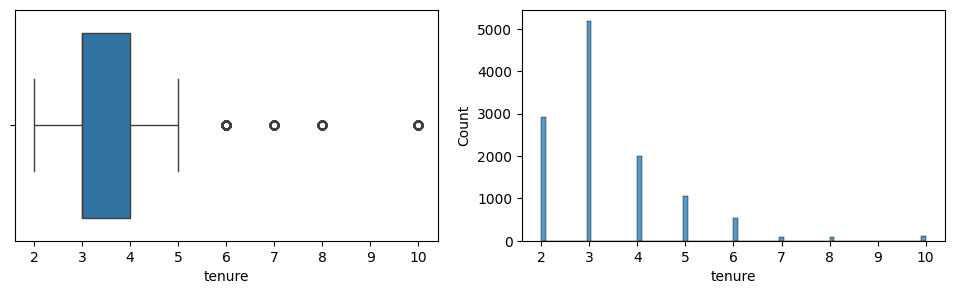

In [10]:
# Tenure
fig, ax = plt.subplots(1, 2, figsize=(12, 3))
sns.boxplot(x=df1['tenure'], ax=ax[0])
sns.histplot(x=df1['tenure'], ax=ax[1])

Several outliers observed for tenures >= 6 years. We will decide if we need to impute or scale these outliers later on our model.

In [11]:
# Determine the number of rows containing outliers
quant75 = df1['tenure'].quantile(0.75)
quant25 = df1['tenure'].quantile(0.25)

iqr = quant75 - quant25

upper_limit = quant75 + (iqr * 1.5)
lower_limit = quant25 - (iqr * 1.5)

print(f'Upper limit: {upper_limit}')
print(f'Lower limit: {lower_limit}')

outliers = df1[(df1['tenure'] > upper_limit) | (df1['tenure'] < lower_limit)]
print(f'Number of rows containing outliers in the tenure column is: {len(outliers)}')

Upper limit: 5.5
Lower limit: 1.5
Number of rows containing outliers in the tenure column is: 824


<Axes: xlabel='satisfaction_level', ylabel='Count'>

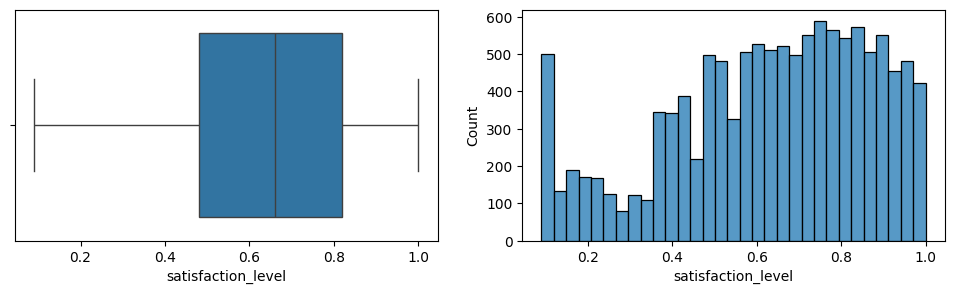

In [12]:
# Satisfaction level 
fig, ax = plt.subplots(1, 2, figsize=(12, 3))
sns.boxplot(x=df1['satisfaction_level'], ax=ax[0])
sns.histplot(x=df1['satisfaction_level'], ax=ax[1])

<Axes: xlabel='last_evaluation', ylabel='Count'>

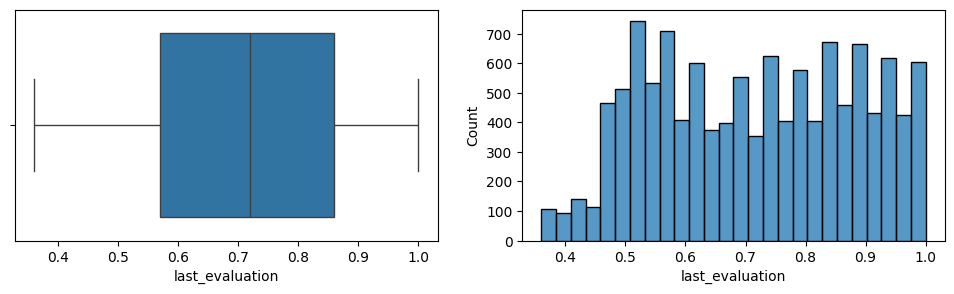

In [13]:
# Last evaluation score
fig, ax = plt.subplots(1, 2, figsize=(12, 3))
sns.boxplot(x=df1['last_evaluation'], ax=ax[0])
sns.histplot(x=df1['last_evaluation'], ax=ax[1])

No outliers for satisfaction_level and last_evaluation. 

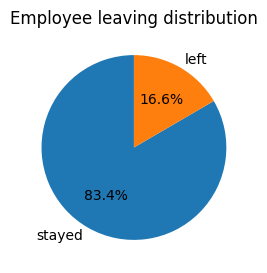

In [14]:
# Distribution for target variable
plt.figure(figsize=(4, 3))
plt.pie(df1['left'].value_counts(), labels=['stayed', 'left'], autopct='%1.1f%%', startangle=90)
plt.title('Employee leaving distribution')
plt.show();

This is a high turnover rate if this is the actual population of the company. For its usage in our machine learning models, the data is slightly imbalanced but not too much. We can safely create our models with this imbalance.

### B. Feature Engineering

I want to build new features extracted from the data first prior to bivariate analysis. Then, we will include this new features in the bivariate analysis.

Standard work week is: 8 hours/day x 5 days/week = 40 hours/week
Standard monthly hours: 40 hours/week x 50 weeks/year = 2000 hours/year x (1 year/12 months) = 166.67 hours/month
Note that only 50 weeks since excluding holidays. This is assumed however, people also have vacation leaves so roughly 50 is a close approximation. 

So the standard monthly hours of work is 166.67 but our data have a very high proportion that works more than those. I want to feature engineer a categorical column that says if an employee is overworked by a threshold monthly hours. I will set 225 hours as the threshold, it roughly equates to 10.8 hours/day too.

In [15]:
# Copy the data first
df2 = df1.copy()

df2['overworked'] = np.where((df2['average_monthly_hours'] > 225), 1, 0)
df2.sample(10, random_state=42)

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary,overworked
397,0.09,0.79,6,293,5,0,1,0,sales,low,1
3107,0.74,0.96,4,154,4,0,0,0,support,medium,0
9331,0.81,0.97,4,212,2,0,0,0,sales,low,0
357,0.37,0.54,2,149,3,0,1,0,support,low,0
1326,0.10,0.77,6,272,4,0,1,0,accounting,low,1
1657,0.11,0.86,6,245,4,0,1,0,support,low,1
5844,0.49,0.92,4,229,2,0,0,0,technical,low,1
9805,0.63,0.82,5,268,3,0,0,0,hr,high,1
10754,0.70,0.73,4,182,3,0,0,0,IT,medium,0
3644,0.73,0.96,2,151,3,0,0,0,technical,medium,0


Next thing I will add is a feature that checks is an employee has a last_evaluation of greater than 0.9, works more than 225 hours monthly, and whether or not the employee is promoted. Having high performance and working great hours without having promotion might cause dissatisfaction for an employee. I will leave some reservation for this feature though since last_evaluation is not representative of previous years of work.

In [16]:
condition = (df2['last_evaluation'] > 0.90) & (df2['average_monthly_hours'] > 225) & (df2['promotion_last_5years'] == 0)
df2['high_perform_no_promotion'] = np.where(condition, 1, 0)
df2.sample(10)

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary,overworked,high_perform_no_promotion
9150,0.88,0.55,5,168,2,0,0,0,product_mng,medium,0,0
3222,0.74,0.74,4,233,2,0,0,0,sales,medium,1,0
8640,0.34,0.88,5,131,6,0,0,0,sales,low,0,0
11227,0.48,0.93,3,150,10,0,0,0,technical,low,0,0
2274,0.92,0.92,3,159,3,0,0,0,IT,low,0,0
4279,0.76,0.62,4,197,3,0,0,0,technical,low,0,0
6210,0.98,0.96,5,183,3,1,0,0,accounting,medium,0,0
5441,0.50,0.60,5,216,3,0,0,0,sales,medium,0,0
4461,0.52,0.63,3,225,3,0,0,0,hr,medium,0,0
8432,0.64,0.50,3,146,3,0,0,0,technical,low,0,0


I also want to add a feature that checks if an employee is scored less than 0.85 in the last_evaluation but he/she is working at least 250 hours per month.

In [17]:
condition = (df2['average_monthly_hours'] > 250) & (df2['last_evaluation'] < 0.85)
df2['high_hours_low_evaluation'] = np.where(condition, 1, 0)
df2.sample(10)

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary,overworked,high_perform_no_promotion,high_hours_low_evaluation
7617,0.59,0.56,5,162,4,0,0,0,IT,low,0,0,0
4284,0.41,0.61,3,185,2,1,0,0,sales,medium,0,0,0
8620,0.74,0.61,3,228,2,1,0,0,IT,low,1,0,0
6743,0.48,0.98,4,174,3,0,0,0,sales,low,0,0,0
4812,0.15,0.91,2,207,3,0,0,0,technical,medium,0,0,0
8333,0.70,0.99,3,167,3,0,0,0,sales,low,0,0,0
3689,0.62,0.63,2,123,2,0,0,0,sales,medium,0,0,0
6253,0.51,1.00,3,168,3,1,0,0,RandD,medium,0,0,0
4084,0.59,0.62,4,227,4,1,0,0,technical,low,1,0,0
5645,0.22,0.78,6,206,6,0,0,0,RandD,low,0,0,0


### C. Bivariate Analysis

In this part, we will examine relationships between features to gain insights to what causes an employee to leave. We will check if there is employee profiles that shows strong effect on employee behavior. 

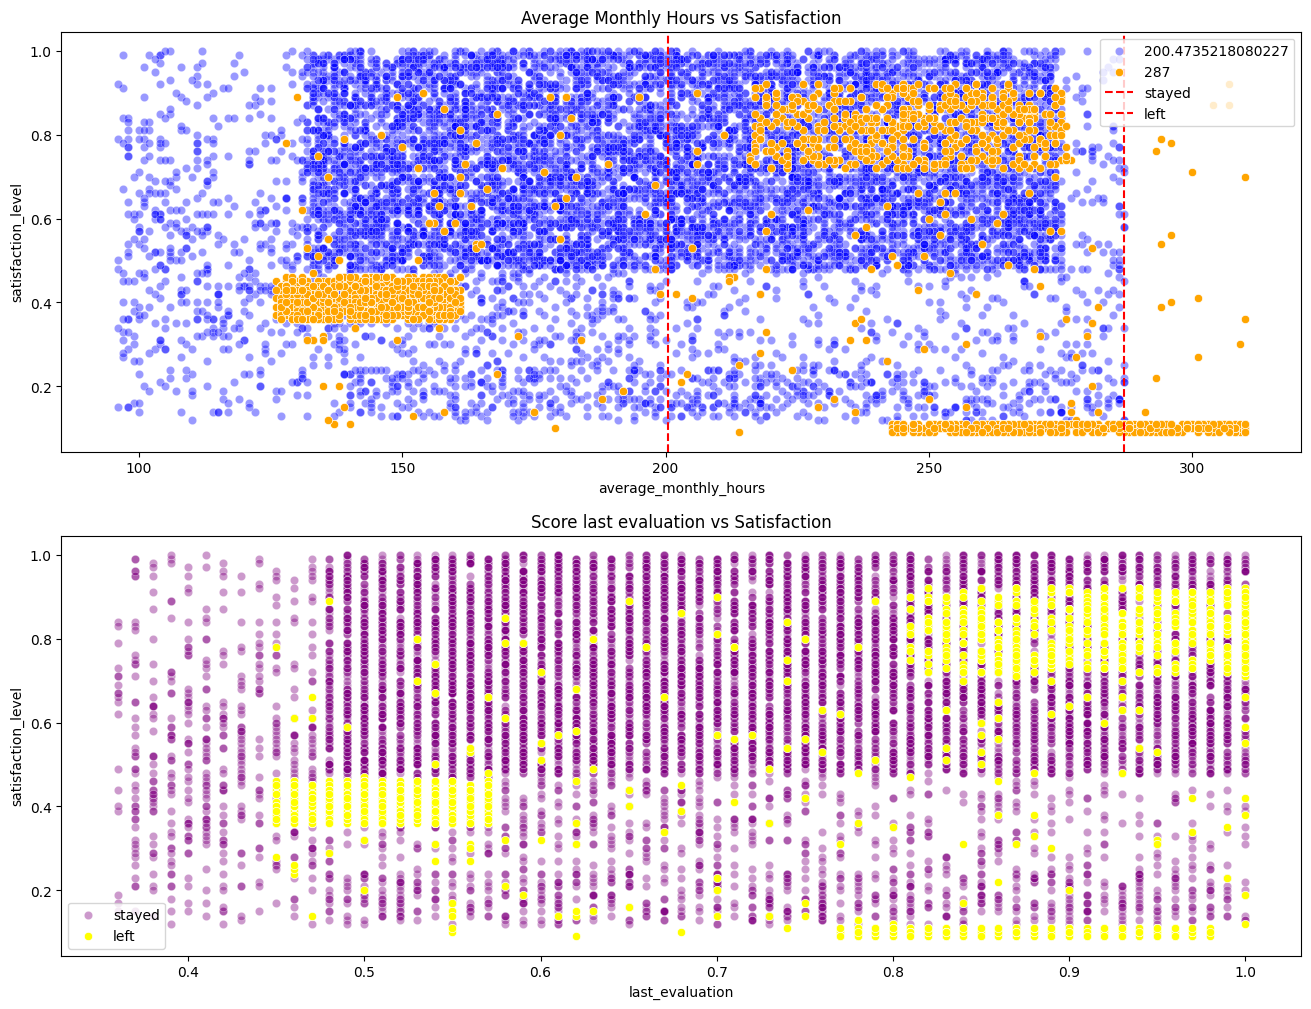

In [18]:
# Average monthly hours vs satisfaction
fig, ax = plt.subplots(2, 1, figsize=(16, 12))

mean = df2['average_monthly_hours'].mean()
max_stayed = df2.loc[df2['left'] == 0, 'average_monthly_hours'].max()

sns.scatterplot(data=df2[df2['left'] == 0], x='average_monthly_hours', y='satisfaction_level', color='blue', alpha=0.4, label='stayed', ax=ax[0])
sns.scatterplot(data=df2[df2['left'] == 1], x='average_monthly_hours', y='satisfaction_level', color='orange', label='left', ax=ax[0])
ax[0].set_title('Average Monthly Hours vs Satisfaction')
ax[0].axvline(x=mean, ls='--', color='red', label=f'mean monthly hrs={mean:.2f}')
ax[0].axvline(x=max_stayed, ls='--', color='red', label=f'max hrs for those who stayed={max_stayed}')
ax[0].legend(labels=[mean, max_stayed,'stayed', 'left'], loc='upper right')

# Last evaluation vs satisfaction
sns.scatterplot(data=df2[df2['left'] == 0], x='last_evaluation', y='satisfaction_level', color='purple', alpha=0.4, label='stayed', ax=ax[1])
sns.scatterplot(data=df2[df2['left'] == 1], x='last_evaluation', y='satisfaction_level', color='yellow', label='left', ax=ax[1])
ax[1].set_title('Score last evaluation vs Satisfaction')
ax[1].legend()

The scatterplot for **average_monthly_hours** vs **satisfaction** shows several clusters for those who left. This might be a strong predictor of why employee leaves. Also, the plot shows that all employees that worked more than 287 hours monthly has left the company. This is also need to be further studied with relations to other features to draw a strong conclusion.
The clusters found are:
1. Those who worked around 125 - 170 hours and have a mid satisfaction level.
2. Those who worked great hours of around 225 - 275 and have a satisfaction level of 0.7 - 0.9.
3. Those who worked greater hours of more than 240 and have a very low satisfaction level below 0.2.

Similar cluster was also found for the scatterplot of last_evaluation score vs satisfaction. 

#### First cluster

In [19]:
# Explore these clusters

# Isolate clusters
df2_a = df2[((df2['average_monthly_hours'] > 125) & (df2['average_monthly_hours'] < 170)) & 
    ((df2['satisfaction_level'] > 0.3) & (df2['satisfaction_level'] < 0.5)) & df2['left'] == 1]
df2_a.describe()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,overworked,high_perform_no_promotion,high_hours_low_evaluation
count,843.000000,843.00000,843.000000,843.000000,843.000000,843.000000,843.0,843.000000,843.0,843.0,843.0
mean,0.407663,0.51433,2.042705,143.581257,3.018980,0.053381,1.0,0.005931,0.0,0.0,0.0
std,0.030818,0.05072,0.381369,10.119194,0.200048,0.224925,0.0,0.076831,0.0,0.0,0.0
min,0.310000,0.45000,2.000000,126.000000,2.000000,0.000000,1.0,0.000000,0.0,0.0,0.0
25%,0.380000,0.48000,2.000000,135.000000,3.000000,0.000000,1.0,0.000000,0.0,0.0,0.0
50%,0.410000,0.51000,2.000000,144.000000,3.000000,0.000000,1.0,0.000000,0.0,0.0,0.0
75%,0.430000,0.54000,2.000000,152.000000,3.000000,0.000000,1.0,0.000000,0.0,0.0,0.0
max,0.470000,1.00000,7.000000,161.000000,6.000000,1.000000,1.0,1.000000,0.0,0.0,0.0


In [20]:
df2_a.number_project.value_counts()

number_project
2    831
6      4
4      4
5      2
7      1
3      1
Name: count, dtype: int64

In [21]:
df2_a.tenure.value_counts()

tenure
3    832
5      5
4      4
6      1
2      1
Name: count, dtype: int64

For the first cluster, observation is that their last evaluation is around **0.48-0.54**. Almost all of them have **only 2** projects and are **3 years** in the company. I think that this group is the low performing individuals, maybe the reason why they were only given two projects. 

The company could look at this profile and create interventions, perhaps invest in their upskilling or have a closed-door meeting to ask them how the company could improve their performance.

In [22]:
# Isolate clusters
df2_b = df2[((df2['average_monthly_hours'] > 220) & (df2['average_monthly_hours'] < 280)) & 
    ((df2['satisfaction_level'] > 0.7) & (df2['satisfaction_level'] < 0.95)) & df2['left'] == 1]
df2_b.describe()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,overworked,high_perform_no_promotion,high_hours_low_evaluation
count,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.0,462.000000,462.000000,462.000000,462.000000
mean,0.819329,0.919524,4.573593,248.889610,5.147186,0.051948,1.0,0.002165,0.930736,0.543290,0.064935
std,0.057871,0.065597,0.545138,15.348262,0.547111,0.222163,0.0,0.046524,0.254178,0.498662,0.246678
min,0.720000,0.530000,2.000000,221.000000,2.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000
25%,0.770000,0.870000,4.000000,237.000000,5.000000,0.000000,1.0,0.000000,1.000000,0.000000,0.000000
50%,0.820000,0.920000,5.000000,249.000000,5.000000,0.000000,1.0,0.000000,1.000000,1.000000,0.000000
75%,0.870000,0.980000,5.000000,262.000000,5.000000,0.000000,1.0,0.000000,1.000000,1.000000,0.000000
max,0.920000,1.000000,6.000000,277.000000,6.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000


<Axes: xlabel='last_evaluation'>

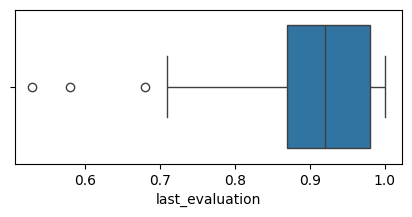

In [23]:
plt.figure(figsize=(5,2))
sns.boxplot(x=df2_b.last_evaluation)

<Axes: xlabel='average_monthly_hours'>

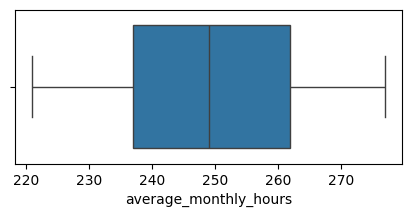

In [24]:
plt.figure(figsize=(5,2))
sns.boxplot(x=df2_b.average_monthly_hours)

In [25]:
df2_b.tenure.value_counts()

tenure
5    363
6     90
2      5
3      3
4      1
Name: count, dtype: int64

In [26]:
df2_b.promotion_last_5years.value_counts()

promotion_last_5years
0    461
1      1
Name: count, dtype: int64

In [27]:
df2_b.salary.value_counts()

salary
low       266
medium    186
high       10
Name: count, dtype: int64

This group have high evaluation scores 0.87 - 0.98, fair satisfaction 0.77 - 0.87. Almost 80% of them are on their 5th year. In terms of the mentioned features, I cannot see a negative connotation for their reason to leave, one feature that can lead to them leaving is the monthly hours which ranges 237 - 262  hours. 

This group is employees who have high evaluation score, satisfied, on their 5th year and work high hours. No obvious reasons except for high working hours (which are also present in employees who did not leave). More data is needed to find a distinct characteristic for this group, perhaps if they have an external offer due to their experience or a company policy that matters at the 5th year. 

In [28]:
# Isolate clusters
df2_c = df2[((df2['average_monthly_hours'] > 240) & (df2['average_monthly_hours'] < 300)) & 
    (df2['satisfaction_level'] < 0.2) & df2['left'] == 1]
df2_c.describe()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,overworked,high_perform_no_promotion,high_hours_low_evaluation
count,415.000000,415.000000,415.000000,415.000000,415.000000,415.000000,415.0,415.000000,415.0,415.000000,415.000000
mean,0.102048,0.868675,6.173494,270.575904,4.103614,0.048193,1.0,0.002410,1.0,0.342169,0.298795
std,0.009626,0.069431,0.604948,16.223333,0.320569,0.214432,0.0,0.049088,0.0,0.475008,0.458282
min,0.090000,0.550000,2.000000,243.000000,3.000000,0.000000,1.0,0.000000,1.0,0.000000,0.000000
25%,0.100000,0.820000,6.000000,256.000000,4.000000,0.000000,1.0,0.000000,1.0,0.000000,0.000000
50%,0.100000,0.870000,6.000000,271.000000,4.000000,0.000000,1.0,0.000000,1.0,0.000000,0.000000
75%,0.110000,0.930000,7.000000,285.000000,4.000000,0.000000,1.0,0.000000,1.0,1.000000,1.000000
max,0.170000,1.000000,7.000000,299.000000,5.000000,1.000000,1.0,1.000000,1.0,1.000000,1.000000


In [29]:
df2_c.number_project.value_counts()

number_project
6    286
7    105
5     18
4      4
3      1
2      1
Name: count, dtype: int64

<Axes: xlabel='average_monthly_hours'>

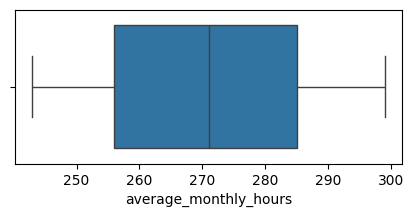

In [30]:
plt.figure(figsize=(5,2))
sns.boxplot(x=df2_c.average_monthly_hours)

In [31]:
df2_c.tenure.value_counts()

tenure
4    368
5     45
3      2
Name: count, dtype: int64

In [32]:
df2_c.promotion_last_5years.value_counts()

promotion_last_5years
0    414
1      1
Name: count, dtype: int64

In [33]:
df2_c.salary.value_counts()

salary
low       241
medium    166
high        8
Name: count, dtype: int64

The third cluster most have evaluations of **0.82 - 0.93**, **256 - 285 hrs** monthly, number of **projects 6-7**, tenure of **4 years**, and not even promoted. I believe this are the reasons this group is disgruntled, satisfaction is only 0.10 for all. This cluster are the high performing employees that I think the company has overworked with high hours and number of projects without the right compensation.

Additional data might be needed to check compensation effect, but my suggestion is to increase their incentives or promote if possible. The company could also cap their number of projects and work hours if they are not able to add more rewards to this group. This group is important and is a huge lost of asset for the company that's why the company should work on this group. 

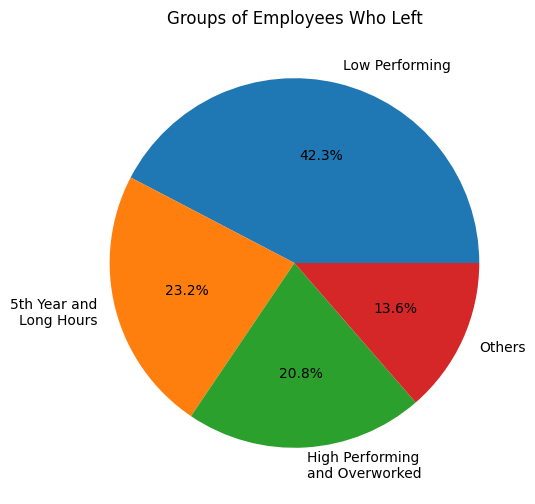

In [34]:
# Pie chart for employee who left and the clusters
others = len(df2[df2['left'] == 1]) - len(df2_a) - len(df2_b) - len(df2_c)
sizes = [len(df2_a), len(df2_b), len(df2_c), others]
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=['Low Performing', '5th Year and\nLong Hours', 'High Performing\nand Overworked', 'Others'], autopct='%1.1f%%')
plt.title('Groups of Employees Who Left')
plt.show();

Text(0.5, 1.0, 'No. of project with turnover profile')

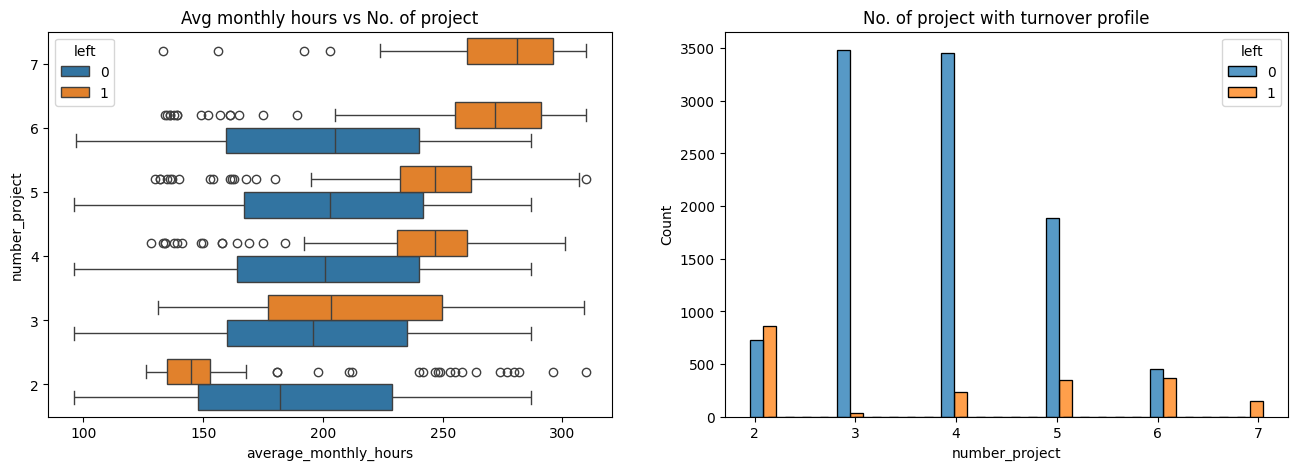

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Boxplot for monthly_hours per different number_project
sns.boxplot(data=df2, x='average_monthly_hours', y='number_project', hue='left', orient='h', ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Avg monthly hours vs No. of project')

# Histplot for number_project with the turnover profile
sns.histplot(data=df2, x='number_project', hue='left', multiple='dodge', shrink=1.5, ax=ax[1])
ax[1].set_title('No. of project with turnover profile')

In the boxplot of **avg_monthly_hours** and **number_project**, the distribution of avg_monthly_hours is fairly close for different number_project for those who stayed. For those who left, the distribution of monthly hours increases per no. of project. It can be observed that those who **leave** have **more hours of worked** more than their peers who have the **same number of projects** except for those who only have two projects. This can mean that overworked employee relative to their peers may feel discontent and causes them to leave.

For the **number_project** and **turnover** profile, it can be observed that employee with **2 and 6** projects have fairly **high turnover rate**. Employees with **7 projects all have left** the company. It can be seen that the optimal number of projects is **3 - 4** where the **turnover ratio is fairly low**.

In [36]:
print('Turnover percent per number of projects')
df1.groupby(['number_project'])['left'].value_counts(normalize=True, sort=False)

Turnover percent per number of projects


number_project  left
2               1       0.541719
                0       0.458281
3               1       0.010795
                0       0.989205
4               0       0.935685
                1       0.064315
5               0       0.846395
                1       0.153605
6               0       0.550847
                1       0.449153
7               1       1.000000
Name: proportion, dtype: float64

Text(0.5, 1.0, 'Bar graph for tenure with turnover profile')

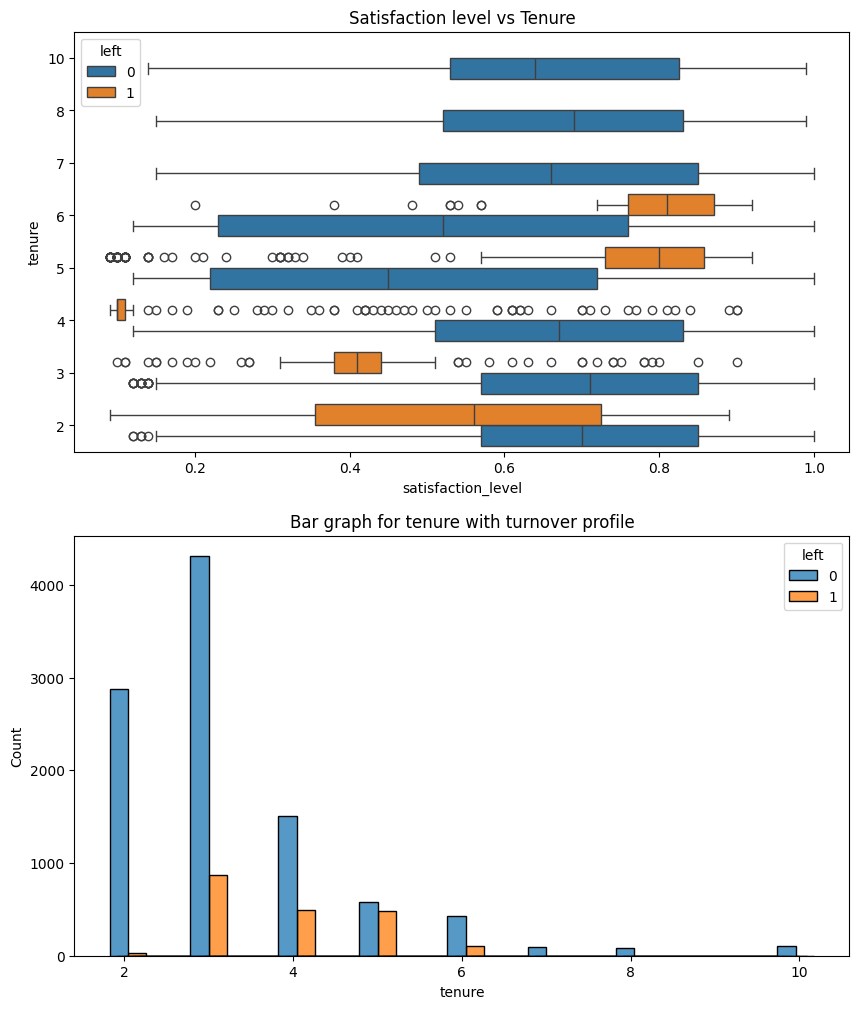

In [37]:
fig, ax = plt.subplots(2, 1, figsize=(10, 12))

# Boxplot for satisfaction_level per years of tenure
sns.boxplot(data=df2, x='satisfaction_level', y='tenure', hue='left', orient='h', ax=ax[0])
ax[0].set_title('Satisfaction level vs Tenure')
ax[0].invert_yaxis()

# Histplot for tenure with the turnover profile
sns.histplot(data=df2, x='tenure', hue='left', multiple='dodge', shrink=5, ax=ax[1])
ax[1].set_title('Bar graph for tenure with turnover profile')

In the **satisfaction_level** vs **tenure** boxplot, it can be observed that those who left have lower satisfaction_level for those who are 2-4 years in the company. Those that are 5-6 years in the company and left have higher satisfaction_level than those who stayed. This can mean that the cause of leaving the company is not discontent for this tenure but a rather different one, perhaps being offered with another oppurtunity. The very low satisfaction for the 4-year tenured employees are align with what we see in one of the clusters. These are the high performing and overworked employees.

The bar graph for tenure and turnover profile shows **higher turnover ratio** for people who are in their **4th-5th year**. Perhaps, the company can check what causes this employee, is it that they have acquired enough experience to find better oppurtunities or they dont feel enough compensation with respect to their experience. 

Employee who have 7 years and more in the company have all stayed.

Text(0.5, 1.0, 'Bar graph for turnover profile per department')

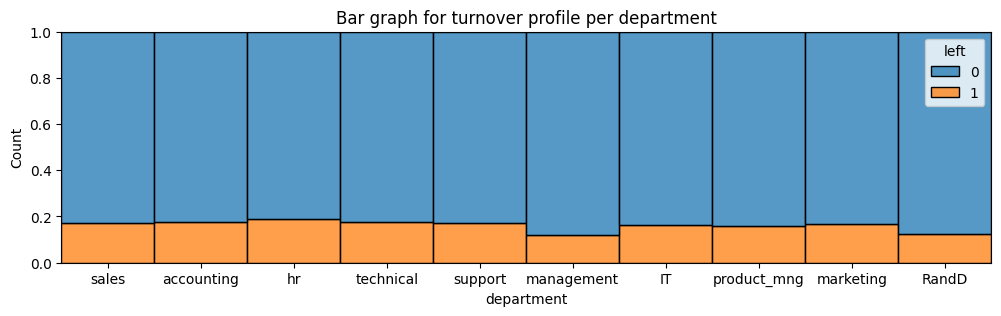

In [38]:
# Histplot for department employees with the turnover profile
plt.figure(figsize=(12, 3))
sns.histplot(data=df2, x='department', hue='left', multiple='fill')
plt.title('Bar graph for turnover profile per department')

Text(0.5, 1.0, 'Employee who have a work accident turnover profile')

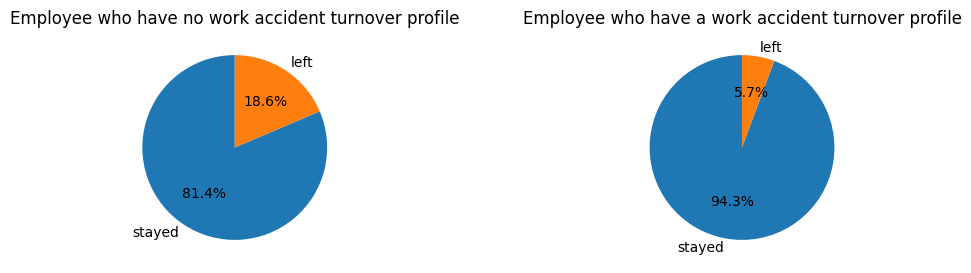

In [39]:
# Pie chart for turnover rate per work_accident
fig, ax = plt.subplots(1, 2, figsize=(12, 3))

plt.subplot(121)
data = df1.loc[df2['work_accident'] == 0, 'left'].value_counts()
plt.pie(data, labels=['stayed', 'left'], autopct='%1.1f%%', startangle=90)
plt.title('Employee who have no work accident turnover profile')

plt.subplot(122)
data = df1.loc[df2['work_accident'] == 1, 'left'].value_counts()
plt.pie(data, labels=['stayed', 'left'], autopct='%1.1f%%', startangle=90)
plt.title('Employee who have a work accident turnover profile')


In [40]:
df2.groupby('work_accident')['left'].value_counts()

work_accident  left
0              0       8255
               1       1886
1              0       1745
               1        105
Name: count, dtype: int64

Percentage of people leaving per department are fairly close. Turnover rate for employee who have no accident is fairly greater than those who have experienced an accident. We can conduct hypothesis testing to conclude if there is a statistically significant difference between these relationships.

Text(0.5, 1.0, 'Box plot of satisfaction level per salary')

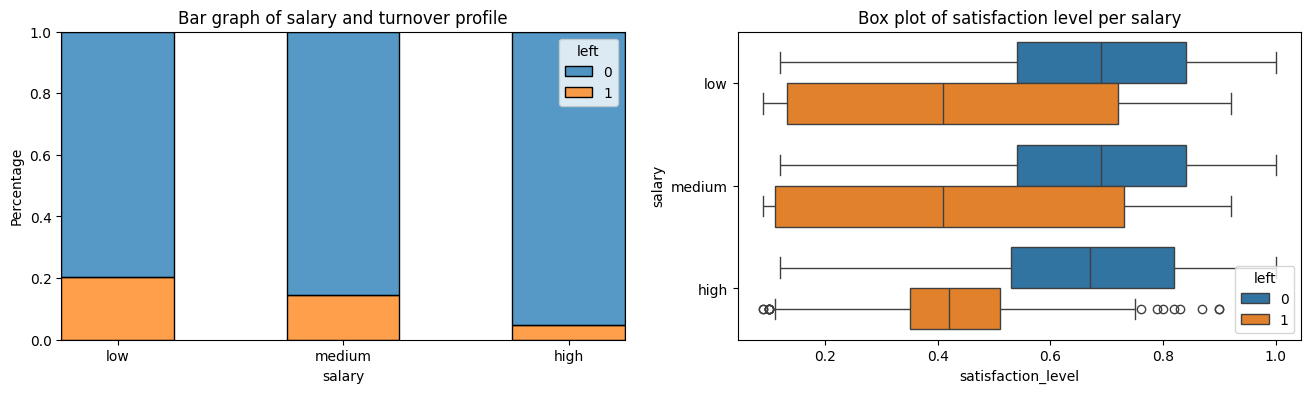

In [41]:
fig, ax = plt.subplots(1, 2, figsize=(16, 4))

# Histplot of salary with turnover profile
sns.histplot(data=df2, x='salary', hue='left', multiple='fill', shrink=0.5, ax=ax[0])
ax[0].set_ylabel('Percentage')
ax[0].set_title('Bar graph of salary and turnover profile')

# Boxplot of satisfaction_level per salary
sns.boxplot(data=df2, x='satisfaction_level', y='salary', hue='left', ax=ax[1])
ax[1].set_title('Box plot of satisfaction level per salary')

In [42]:
df2.dtypes

satisfaction_level           float64
last_evaluation              float64
number_project                 int64
average_monthly_hours          int64
tenure                         int64
work_accident                  int64
left                           int64
promotion_last_5years          int64
department                       str
salary                           str
overworked                     int64
high_perform_no_promotion      int64
high_hours_low_evaluation      int64
dtype: object

In [43]:
df2.groupby(['salary', 'left'])[['satisfaction_level']].agg(['mean', 'median', 'std', 'count'])

satisfaction_level                       
                          mean median       std count
salary left                                          
high   0              0.653832   0.67  0.220576   942
       1              0.437500   0.42  0.246977    48
low    0              0.669457   0.69  0.218699  4566
       1              0.440630   0.41  0.264174  1174
medium 0              0.668077   0.69  0.214629  4492
       1              0.439896   0.41  0.268185   769

In [44]:
df1.groupby('salary')['left'].value_counts(normalize=True, sort=False)

salary  left
high    1       0.048485
        0       0.951515
low     1       0.204530
        0       0.795470
medium  1       0.146170
        0       0.853830
Name: proportion, dtype: float64

The plot for the **salary** and **turnover** shows that the percentage is **higher for lower salary** compared to those higher. The box plot for the **satisfaction_level** and **salary** generally shows that people who **leave** have a **lower satisfaction** however, the mean value doesn't change for different salaries. This can signify that satisfaction is independent of salary level.

We can conduct a chi-square to determine if salary affect the likelihood of living and one-way anova to determine if there is a significant difference for satisfaction level and salary level.

Text(0.5, 1.0, 'Percentage of promotion based on average monthly hours for those who stayed')

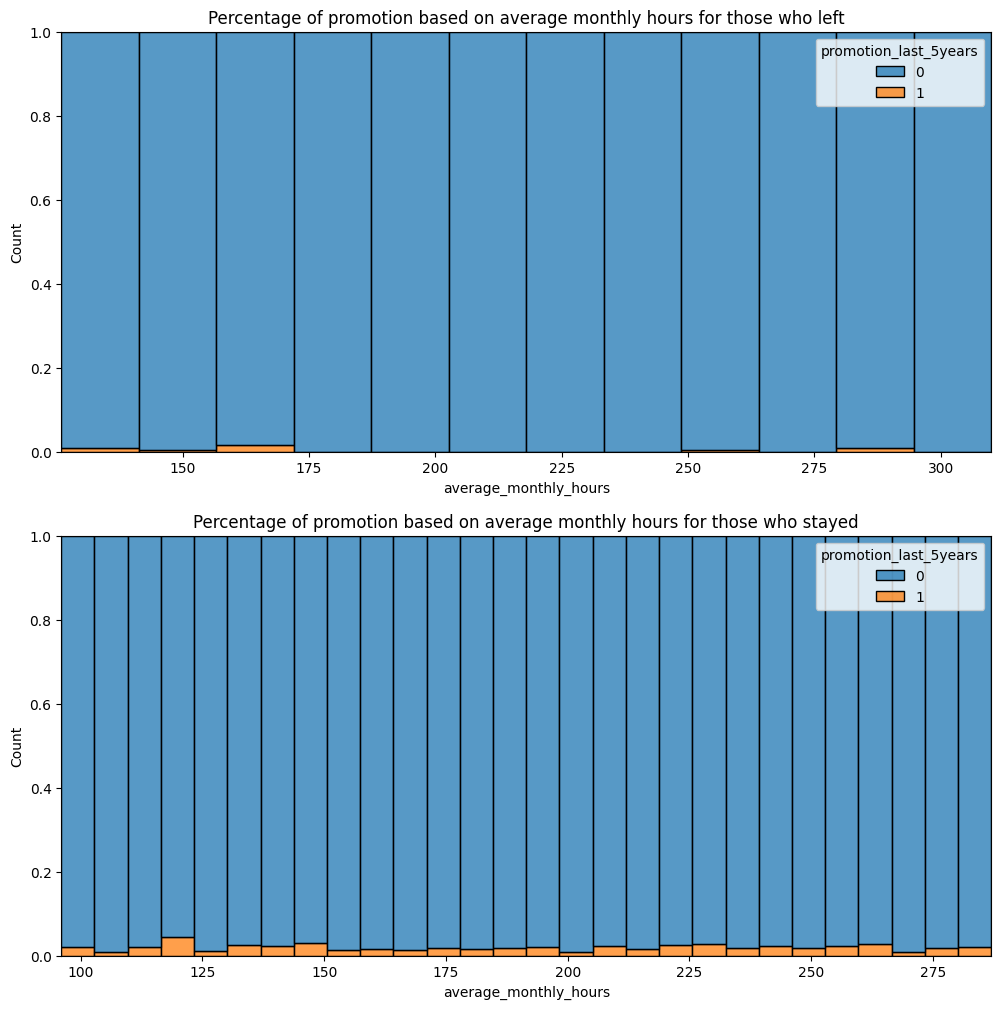

In [45]:
fig, ax = plt.subplots(2, 1, figsize=(12, 12))

# Histplot of monthly working hours for employee who stayed
sns.histplot(data=df2[df2['left'] == 1], x='average_monthly_hours', hue='promotion_last_5years', multiple='fill', ax=ax[0])
ax[0].set_title('Percentage of promotion based on average monthly hours for those who left')

# Histplot of monthly working hours for employee who left
sns.histplot(data=df2[df2['left'] == 0], x='average_monthly_hours', hue='promotion_last_5years', multiple='fill', ax=ax[1])
ax[1].set_title('Percentage of promotion based on average monthly hours for those who stayed')

The data shows smaller percentage of promotion for those that left compared to those who stayed. Let's create another clearer visualization to see their difference.

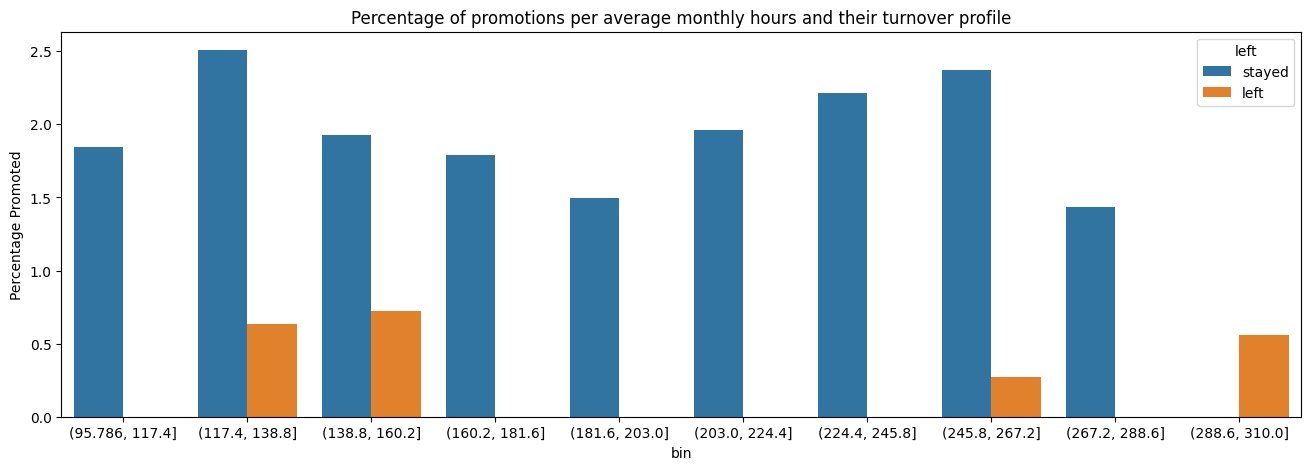

In [46]:
plt.figure(figsize=(16,5))

subset = df2.copy()
subset['bin'] = pd.cut(subset['average_monthly_hours'], bins=10)
bins_agg = subset.groupby(['bin', 'left'])['promotion_last_5years'].mean()
bins_agg = bins_agg.reset_index()
bins_agg['promotion_last_5years'] = bins_agg['promotion_last_5years'] * 100

fig = sns.barplot(data=bins_agg, x='bin', y='promotion_last_5years', hue='left', dodge=True)
plt.title('Percentage of promotions per average monthly hours and their turnover profile')
plt.ylabel('Percentage Promoted')
handles, labels = fig.get_legend_handles_labels()
plt.legend(title='left', handles=handles, labels=['stayed', 'left'], loc='upper right')

The percentage of promotions for those who stayed are around 1.5% - 2.5% which vary across working hours. There is a lower percentage for those who left with some bins having 0%. It can be observed that employee who left have lower promotion rate but the percentage for both cohorts are very small compared to the total population. This might suggest a small effect in the total population. 

A chi-square test of independence can determine if promotion over the last 5 years affect the likelihood of an employee leaving.

There is no descernible pattern too that can be seen in the promotion rate as working hours increases.

In [47]:
print('Overview of promotion rate')
print(df2['promotion_last_5years'].value_counts(normalize=True))
print('Overall promotion percentage is just 1.7%')

Overview of promotion rate
promotion_last_5years
0    0.983071
1    0.016929
Name: proportion, dtype: float64
Overall promotion percentage is just 1.7%


Text(0.5, 1.0, 'Correlation Heatmap')

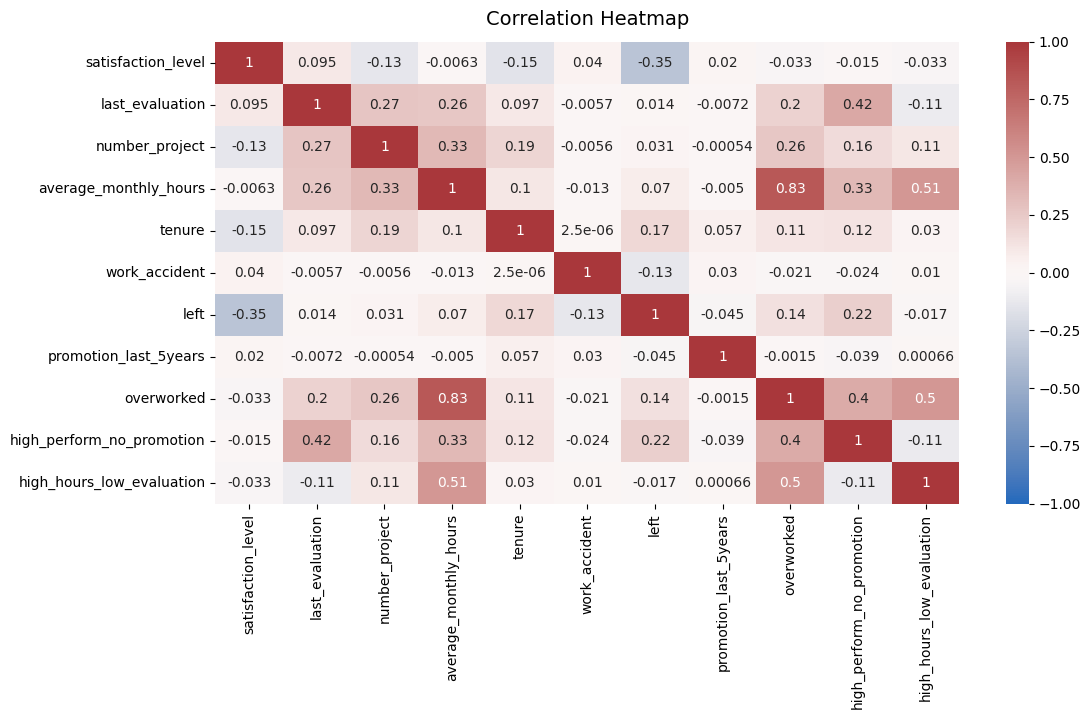

In [48]:
# Correlation heatmap
corr = df2.corr(numeric_only=True)
plt.figure(figsize=(12, 6))
heatmap = sns.heatmap(corr, vmin=-1, vmax=1, annot=True, cmap=sns.color_palette("vlag", as_cmap=True))
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':14}, pad=12)

#### Insights

Employees leaving the company are tied to several reasons. For a similar project number, employees who leave are those who worked more hours. The optimum number of project to that have the lowest turnover ratio is 3-4 projects. For years in the company, close to half of the people who are in their 5th year leave the company. Employee who have 7 and more years tend to stay in the company. Departments have fairly close turnover ratio, no single department is the reason for employee leaving.

Three groups have been identified where employees experienced the same reasons why they leave. The first is low performing employees in their 3rd year and only given 2 projects. Second are employees with high performance, fairly satisfied, work long hours, and on their 5th year. This group might need further analysis and data to find the distinct characteristic why they leave. Third are the high performing employees that felt very unsatisfied with high hours overworking, 6-7 projects, and are not highly paid or even promoted. I suggest that the company provide importance to this group as the cost for replacing this group is quite high due to their high performance and they have 4 years worth of company knowledge. 

## 3. Hypothesis Testing

#### Chi-Square Test of Independence for Leaving and Salary

For the first hypothesis test, we will check if leaving is affected by salary. Our visualization shows that employee in the low salary bracket has the highest turnover ratio compared to higher brackets. We will conduct a chi-square test of independence at a 95% confidence level to determine if this is statistically significant or just due to randomness. 

The boxplot of satisfaction level with different salary brackets reveal that satisfaction is really lower for those who left. However, the mean satisfaction almost doesn't change for different salary. This can suggest that regardless of the salary, unsatisfied employees just leave the company. This will align with the null hypothesis and if the null hypothesis is true, we can rule out salary as a cause of leaving and focus on other features.

For chi-square test of independence, the hypotheses are:<br>
> Null: Employee leaving is independent of salary bracket<br>
> Alternative: Employee leaving is affected by salary bracket

In [49]:
from scipy.stats import chi2_contingency

# Prepare crosstab
contingency = pd.crosstab(df2['salary'], df2['left'])

# Conduct chi-square test of independence
chi2, p, dof, expected = chi2_contingency(contingency)
print('Chi-square:', chi2)
print('p-value:', p)
print('Degrees of freedom:', dof)

Chi-square: 175.21071935727466
p-value: 8.984123357404531e-39
Degrees of freedom: 2


#### Conclude
Our p-value is very small compared to 0.05 (95% confidence level). This means that we reject the null hypothesis and that employee leaving is affected by salary bracket.

#### Monthly Hours of Employees who left vs stayed (controlling for number of projects)

The boxplot for monthly hours work of employees who left vs those who stayed shows higher hours for those who left. This observation is present in number of projects from 3 - 6 (7 not included since all have left). Let us confirm this observation statistically by performing a Analysis of Covariance test. First we will confirm that there is no interaction between leaving and number of projects as this is an assumption for ANCOVA.

We will use a 95% confidence level again.

Hypotheses:<br>
> Null: Average monthly hours of work are equal for employees who stay and leave<br>
> Alternative: Average monthly hours of work is greater for employee who leave than those who stayed

In [50]:
# !pip3 install statsmodels

In [51]:
import statsmodels.formula.api as smf

# Let's filter the data first since we want to conclude that this happens for number of projects 3-6
data = df2.copy()[(df2['number_project'] >= 3) & (df2['number_project'] <= 6)]

# Check for parallel slope assumption
model_interaction = smf.ols('average_monthly_hours ~ left * number_project', data=data).fit()
print(model_interaction.summary())

                              OLS Regression Results                             
Dep. Variable:     average_monthly_hours   R-squared:                       0.117
Model:                               OLS   Adj. R-squared:                  0.117
Method:                    Least Squares   F-statistic:                     454.2
Date:                   Tue, 24 Feb 2026   Prob (F-statistic):          4.18e-277
Time:                           14:09:21   Log-Likelihood:                -53404.
No. Observations:                  10264   AIC:                         1.068e+05
Df Residuals:                      10260   BIC:                         1.068e+05
Df Model:                              3                                         
Covariance Type:               nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Inte

p-value for left: number_project is 0.000 which is below 0.05. This means that ANCOVA assumption is not satisfied, there is an interaction between number of projects and leaving the company. We cannot generalize monthly hours difference for all the projects.

We can conduct a simple effect analysis using two-sample t-test to check if there is a significant difference for monthly working hours of those who leave compared to those who did not. We will do this for different number of projects. 

Hypotheses:<br>
> Null: Average monthly hours of work are equal for employees who stay and leave<br>
> Alternative: Average monthly hours of work is greater for employee who leave than those who stayed

In [52]:
from scipy.stats import ttest_ind

for num_proj in range(3, 7):
    subset = df2.copy()[df2['number_project'] == num_proj]

    left_group = subset[subset['left'] == 1]['average_monthly_hours']
    stay_group = subset[subset['left'] == 0]['average_monthly_hours']

    results = ttest_ind(left_group, stay_group, equal_var=False)
    print('Two-sample t-test result for num_project:', num_proj)
    print('pvalue:', results.pvalue)
    if results.pvalue < 0.0125:
        print('Significant at alpha=0.0125')
    else:
        print('Not significant at alpha=0.0125')

    print()

Two-sample t-test result for num_project: 3
pvalue: 0.07886186733468531
Not significant at alpha=0.0125

Two-sample t-test result for num_project: 4
pvalue: 4.467074067899076e-54
Significant at alpha=0.0125

Two-sample t-test result for num_project: 5
pvalue: 3.531717748405608e-86
Significant at alpha=0.0125

Two-sample t-test result for num_project: 6
pvalue: 2.9339169330808067e-96
Significant at alpha=0.0125



#### Conclude
The simple effect analysis shows that average_monthly_hours is significantly higher for those who left the company compared to those who stayed when number of projects reach 4-6.

## 4. Data Modelling and Evaluation

Three models will be trained and tested:
1. Logistic Regression
2. Random Forest
3. XGBoost

Main metric we will use is ROC AUC score since we want to rank positive heavier than negative. Also, the cost of false positive and false negative is not yet established and might be just close to equal. 

#### Imports and Assistant Functions

In [53]:
# Import necessary libraries

# Modelling algorithms
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier, plot_importance

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.tree import plot_tree

In [54]:
# Preparing useful functions
import os

# Score recording functions assistant
def make_results(model_name, model_object, metric):
    metric_dict = {
        'auc': 'mean_test_roc_auc',
        'precision': 'mean_test_precision',
        'recall': 'mean_test_recall',
        'f1': 'mean_test_f1',
        'accuracy': 'mean_test_accuracy'
    }
    
    cv_results = pd.DataFrame(model_object.cv_results_)
    res = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]
    
    auc = res.mean_test_roc_auc
    precision = res.mean_test_precision
    recall = res.mean_test_recall
    f1 = res.mean_test_f1
    accuracy = res.mean_test_accuracy
    
    results = pd.DataFrame({
        'model': [model_name],
        'auc': [auc],
        'precision': [precision],
        'recall': [recall],
        'f1': [f1],
        'accuracy': [accuracy]
    })
    
    return results
    

def get_scores(model_name, model_object, X_test, y_test):
    y_pred = model_object.predict(X_test)
    y_pred_proba = model_object.predict_proba(X_test)[:, 1]
    
    auc = roc_auc_score(y_test, y_pred_proba)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    
    results = pd.DataFrame({
        'model': [model_name],
        'auc': [auc],
        'precision': [precision],
        'recall': [recall],
        'f1': [f1],
        'accuracy': [accuracy]
    })
    
    return results

# This is the directory we will save our models
path = 'models/'
os.makedirs(path, exist_ok=True)

# Pickle functions
def save_model(path, model_name, model_object):
    path = os.path.join(path, f'{model_name}.pickle')
    with open(path, 'wb') as to_write:
        pickle.dump(model_object, to_write)

def read_model(path, model_name):
    path = os.path.join(path, f'{model_name}.pickle')
    with open(path, 'rb') as to_read:
        model = pickle.load(to_read)
    return model

# Confusion matrix display
def cm_disp(y_test, y_pred, clf):
    cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
    disp.plot(values_format='')

#### Final Data Preparation

Before creating our predictive models, let us finalize the data which includes transforming non-numeric features and splitting the data into training and testing sets. 

We will remove satisfaction because I've actually tested this project before and scores are extremely high, I am suspecting that satisfaction_level is causing data leakage to the training data. Also, satisfaction level is somewhat a result of the other features so it is also a dependent variable 
(good experience results to high satisfaction). We want to study independent variables which the employees experience in the company.

High scores are generally good but what if we want to predict if an employee will leave during certain situations. Usually satisfaction maybe surveyed periodically or if an employee will leave. If we want to predict if an employee will leave, we cannot use the model if we dont have the satisfaction data yet.

In [55]:
df2.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary,overworked,high_perform_no_promotion,high_hours_low_evaluation
0,0.38,0.53,2,157,3,0,1,0,sales,low,0,0,0
1,0.80,0.86,5,262,6,0,1,0,sales,medium,1,0,0
2,0.11,0.88,7,272,4,0,1,0,sales,medium,1,0,0
3,0.72,0.87,5,223,5,0,1,0,sales,low,0,0,0
4,0.37,0.52,2,159,3,0,1,0,sales,low,0,0,0


In [56]:
df_model = df2.copy()

df_model = df_model.drop('satisfaction_level', axis=1)
df_model['salary'] = df_model['salary'].map({
    'low': 1,
    'medium': 2,
    'high': 3
})

df_model = pd.get_dummies(df_model, drop_first=True, dtype=int)

In [57]:
df_model.sample(10)

,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,overworked,high_perform_no_promotion,high_hours_low_evaluation,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
6118,0.87,4,194,4,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0
5480,0.66,3,256,2,0,0,0,2,1,0,1,0,0,0,0,0,0,0,0,0
6532,0.79,4,176,4,1,0,0,2,0,0,0,0,0,0,0,0,0,0,1,0
8621,0.74,5,165,2,0,0,0,2,0,0,0,1,0,0,0,0,0,0,0,0
655,1.00,4,232,5,0,1,0,2,1,1,0,0,0,0,0,0,0,0,0,1
5972,0.61,3,253,2,0,0,0,2,1,0,1,0,0,0,0,0,0,1,0,0
310,0.93,7,305,4,0,1,0,2,1,1,0,0,0,0,0,0,0,0,0,1
9664,0.68,4,204,4,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0
3178,0.83,4,145,4,0,0,0,2,0,0,0,0,0,0,0,0,0,0,1,0
8028,0.99,4,272,2,0,0,0,2,1,1,0,0,0,0,0,0,0,1,0,0


In [58]:
df_model.dtypes

last_evaluation              float64
number_project                 int64
average_monthly_hours          int64
tenure                         int64
work_accident                  int64
left                           int64
promotion_last_5years          int64
salary                         int64
overworked                     int64
high_perform_no_promotion      int64
high_hours_low_evaluation      int64
department_RandD               int64
department_accounting          int64
department_hr                  int64
department_management          int64
department_marketing           int64
department_product_mng         int64
department_sales               int64
department_support             int64
department_technical           int64
dtype: object

In [59]:
# Splitting the data
X = df_model.copy().drop('left', axis=1)
y = df_model['left']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

### Logistic Regression Model

To build our logistic regression model, we will scale the features first except for the binary ones. Log transform will also be performed for the `tenure` feature due to the outliers present.

In [60]:
df_model.head()

,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,overworked,high_perform_no_promotion,high_hours_low_evaluation,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.53,2,157,3,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0
1,0.86,5,262,6,0,1,0,2,1,0,0,0,0,0,0,0,0,1,0,0
2,0.88,7,272,4,0,1,0,2,1,0,0,0,0,0,0,0,0,1,0,0
3,0.87,5,223,5,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0
4,0.52,2,159,3,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0


In [61]:
# We must create own copy of testing set because we only want to use scaled data for the Logistic Regression Model
X_lr_train = X_train.copy()
X_lr_test = X_test.copy()

X_lr_train['tenure'] = np.log1p(X_lr_train['tenure'])
X_lr_test['tenure'] = np.log1p(X_lr_test['tenure'])

features_to_scale = ['last_evaluation', 'number_project', 'average_monthly_hours', 'tenure']

scaler = StandardScaler()
X_lr_train[features_to_scale] = scaler.fit_transform(X_lr_train[features_to_scale])
X_lr_test[features_to_scale] = scaler.transform(X_lr_test[features_to_scale])

In [62]:
lr = LogisticRegression(random_state=42, max_iter=500)
lr_clf = lr.fit(X_lr_train, y_train)

In [63]:
print('Model coefficients')
coef = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_clf.coef_[0],
    'Odds': np.exp(lr_clf.coef_[0])
})
coef['Abs Coefficient'] = np.abs(coef['Coefficient'])
coef.sort_values('Abs Coefficient', ascending=False).drop('Abs Coefficient', axis=1)

Model coefficients


,Feature,Coefficient,Odds
8,high_perform_no_promotion,1.512005,4.535818
4,work_accident,-1.369473,0.254241
5,promotion_last_5years,-1.061059,0.346089
7,overworked,1.053925,2.868890
6,salary,-0.612842,0.541809
3,tenure,0.601911,1.825604
13,department_management,-0.380192,0.683730
2,average_monthly_hours,-0.328485,0.720014
0,last_evaluation,-0.315776,0.729223
10,department_RandD,-0.298233,0.742128


The features that greatly affect the model are:
For categorical variables: high_perform_no_promotion, work_accident, promotion_last_5years, overworked
For continuous and discrete: salary, tenure, average_monthly_hours, last_evaluation

high_perform_no_promotion is a engineered feature that identifies employees who have last_evaluation > 0.9, works > 225 hrs and no promotion received. This resulted to be a strong predictor which is quite intuitive since overworking and performing better without having been promoted will likely increase employee decision to leave to find better environments. 

For work_accident, further study and data may be needed since the negative coefficient means that having no work accident increases the likelihood the employee will leave which is quite counter-intuitive. 

salary has a negative strong coefficient which means that the lower the salary, it is more likely that an employee will leave. This is aligned to our earlier hypothesis testing (chi-square) which concludes that employee leaving is affected with employee salary.

In [64]:
# save and load the model
# save_model(path, 'log_reg_clf', lr_clf)
lr_clf = read_model(path, 'log_reg_clf')

We need to confirm assumptions for a Logistic Regression Model

From the correlation heatmap before, we can see that there is no multicollinearity between the independent variables.

Let's check relationship for logit and one feature which is tenure

Text(0.5, 1.0, 'Log-odds vs Tenure')

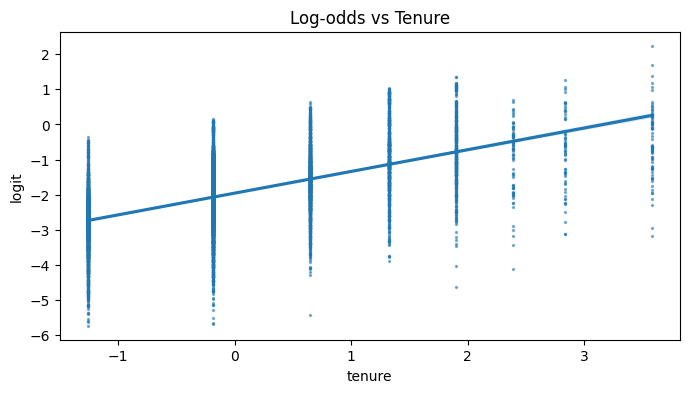

In [65]:
logit_data = X_lr_train.copy()
training_proba = lr_clf.predict_proba(X_lr_train)
logit_data['logit'] = [np.log(proba[1] / proba[0]) for proba in training_proba]

plt.figure(figsize=(8, 4))
sns.regplot(data=logit_data, x='tenure', y='logit', scatter_kws={'s': 2, 'alpha': 0.5})
plt.title('Log-odds vs Tenure')

Relationship shows an upward trend but not quite strong. Nevertheless, let's continue evaluating our logistic regression model.

In [66]:
scores = get_scores('Logistic Regression Classifier', lr_clf, X_lr_test, y_test)
scores

,model,auc,precision,recall,f1,accuracy
0,Logistic Regression Classifier,0.786516,0.57971,0.160643,0.251572,0.841227


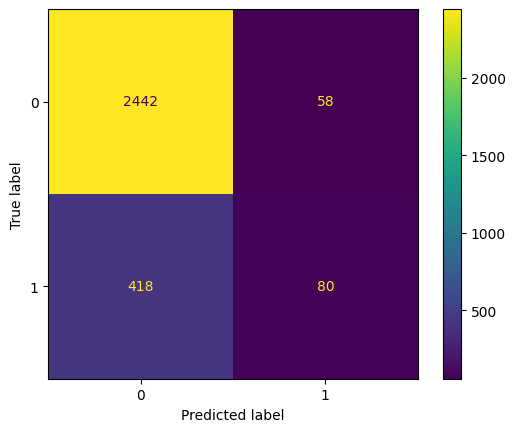

In [67]:
# Confusion Matrix
y_pred = lr_clf.predict(X_lr_test)
cm_disp(y_test, y_pred, lr_clf)

We can see that the model is not strong in predicting the positive cases. Precision is at 57% and recall is only 16%. The reasons for this may stem from the class imbalance of the `left` variable. The model has 84% accuracy but this is only the result of the many negative cases prediction which drowns the positive, this is not good since the positive is what we are trying to predict. 

Another reason is that the linearity assumption of the logistic regression model is not satisfied. As we can see, tenure does not show a strong linear relationship with the log-odds of the predicted probability. This means that the model is not appropriate for the data, thus, the poor performance. 

In [68]:
target_names = ['Predicted would not leave', 'Predicted would leave']
print(classification_report(y_test, y_pred, target_names=target_names))

                           precision    recall  f1-score   support

Predicted would not leave       0.85      0.98      0.91      2500
    Predicted would leave       0.58      0.16      0.25       498

                 accuracy                           0.84      2998
                macro avg       0.72      0.57      0.58      2998
             weighted avg       0.81      0.84      0.80      2998



In [69]:
# Save the scores to the results. This is where we will save our models' scores
results = scores

### Random Forest Classifier

In [70]:
cv_params = {
    'max_depth': [3, 5, 7, None],
    'min_samples_leaf': [1, 2, 3],
    'min_samples_split': [2, 3, 4],
    'max_features': ['sqrt'],
    'n_estimators': [200, 300, 400]
}

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

rf = RandomForestClassifier(random_state=42)

rf_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='roc_auc')

%%time

rf_cv.fit(X_train, y_train)

save_model(path, 'rf_cv', rf_cv)

In [71]:
rf_cv = read_model(path, 'rf_cv')

In [72]:
print('Random Forest CV best score:', rf_cv.best_score_)
print('Random Forest CV best params:', rf_cv.best_params_)

Random Forest CV best score: 0.9752160303555982
Random Forest CV best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 400}


In [73]:
rf_scores = make_results('Random Forest CV', rf_cv, 'auc')
rf_scores

,model,auc,precision,recall,f1,accuracy
0,Random Forest CV,0.975216,0.931835,0.886813,0.908694,0.970421


In [74]:
rf_cv_best = rf_cv.best_estimator_
rf_best_test = get_scores('Random Forest Test Scores', rf_cv_best, X_test, y_test)
rf_best_test

,model,auc,precision,recall,f1,accuracy
0,Random Forest Test Scores,0.969631,0.947034,0.89759,0.921649,0.97465


In [75]:
results = pd.concat([results, rf_scores, rf_best_test])
results

,model,auc,precision,recall,f1,accuracy
0,Logistic Regression Classifier,0.786516,0.579710,0.160643,0.251572,0.841227
0,Random Forest CV,0.975216,0.931835,0.886813,0.908694,0.970421
0,Random Forest Test Scores,0.969631,0.947034,0.897590,0.921649,0.974650


The random forest model produced very high scores with our main metric roc-auc score of 0.98 on cross-validation and 0.97 on the testing data. Our model performed well on training and testing data. The precision and recall are 0.95 and 0.90 respectively. This means that the random forest model is a good predictor for employee leaving.

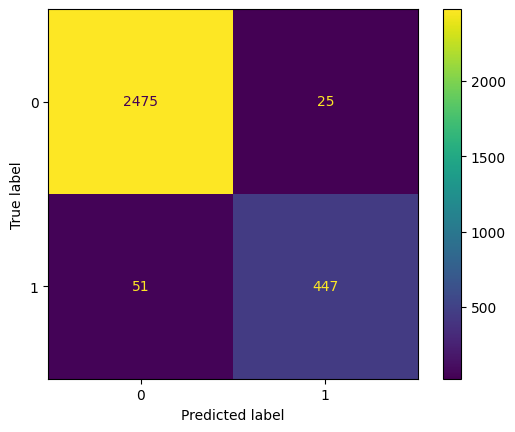

In [79]:
# Check confusion matrix

y_pred_rf = rf_cv_best.predict(X_test)
cm_disp(y_test, y_pred_rf, rf_cv_best);

In [90]:
features_weight = pd.Series(rf_cv_best.feature_importances_, index=X.columns).sort_values(ascending=False)
features_weight

number_project               0.310693
average_monthly_hours        0.207227
tenure                       0.195590
last_evaluation              0.168384
overworked                   0.040239
high_perform_no_promotion    0.029954
salary                       0.013942
work_accident                0.010793
high_hours_low_evaluation    0.006374
department_sales             0.003504
department_technical         0.002821
department_support           0.002435
department_product_mng       0.001429
department_RandD             0.001323
department_accounting        0.001186
department_marketing         0.001157
department_hr                0.001080
promotion_last_5years        0.001029
department_management        0.000840
dtype: float64

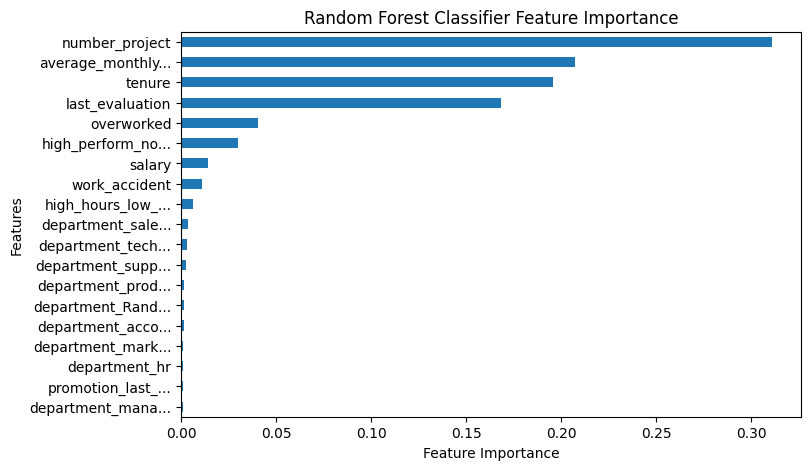

In [94]:
plt.figure(figsize=(8, 5))

features_weight = features_weight.sort_values(ascending=True)
features_weight.index = [col[:15] + '...' if len(col) > 15 else col for col in features_weight.index]
features_weight.plot.barh();

plt.title('Random Forest Classifier Feature Importance')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.show()

The top features that predict the employee will leave are number of projects, average monthly hours, tenure, last evaluation score, and our engineered features of being overworked and high performing with no promotion. This means that these features have great impact in predicting. We must note though that this does not represent direction and such that we cannot directly say that if a feature increase, it will increase likelihood of leaving.

### eXtreme Gradient Boosting

We will not use a GridSearchCV for XGBoost model. We already have a good model to get our conclusions and predictions from. The purpose of this is to test if an XGB model also performs well with the data. 
<br><br>
*P.S. Real reason is my personal device cannot handle XGBoost training LOL :D We can try GridSearch with a cloud or a device with enough compute resources*

In [83]:
# We will use a validation set. This can also help hasten training (less data though)

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic', 
    random_state=42, 
    n_jobs=4,
    tree_method='hist',
    early_stopping_rounds=20
)

In [84]:
%%time

xgb_model.fit(
    X_tr,
    y_tr,
    eval_set=[(X_val, y_val)],
    verbose=True
)

[0]	validation_0-logloss:0.39210
[1]	validation_0-logloss:0.35073
[2]	validation_0-logloss:0.31468
[3]	validation_0-logloss:0.28709
[4]	validation_0-logloss:0.27452
[5]	validation_0-logloss:0.25836
[6]	validation_0-logloss:0.24064
[7]	validation_0-logloss:0.22496
[8]	validation_0-logloss:0.21253
[9]	validation_0-logloss:0.20075
[10]	validation_0-logloss:0.19350
[11]	validation_0-logloss:0.18578
[12]	validation_0-logloss:0.18073
[13]	validation_0-logloss:0.17087
[14]	validation_0-logloss:0.16328
[15]	validation_0-logloss:0.15724
[16]	validation_0-logloss:0.15332
[17]	validation_0-logloss:0.15093
[18]	validation_0-logloss:0.14653
[19]	validation_0-logloss:0.14203
[20]	validation_0-logloss:0.13891
[21]	validation_0-logloss:0.13703
[22]	validation_0-logloss:0.13231
[23]	validation_0-logloss:0.13023
[24]	validation_0-logloss:0.12804
[25]	validation_0-logloss:0.12453
[26]	validation_0-logloss:0.12342
[27]	validation_0-logloss:0.12019
[28]	validation_0-logloss:0.11889
[29]	validation_0-loglos

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",20
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [85]:
save_model(path, 'xgboost', xgb_model)

In [86]:
xgb_model = read_model(path, 'xgboost')

In [87]:
xgb_test = get_scores('XGBoost Test Scores', xgb_model, X_test, y_test)
results = pd.concat([results, xgb_test])
results

,model,auc,precision,recall,f1,accuracy
0,Logistic Regression Classifier,0.786516,0.579710,0.160643,0.251572,0.841227
0,Random Forest CV,0.975216,0.931835,0.886813,0.908694,0.970421
0,Random Forest Test Scores,0.969631,0.947034,0.897590,0.921649,0.974650
0,XGBoost Test Scores,0.972794,0.923868,0.901606,0.912602,0.971314


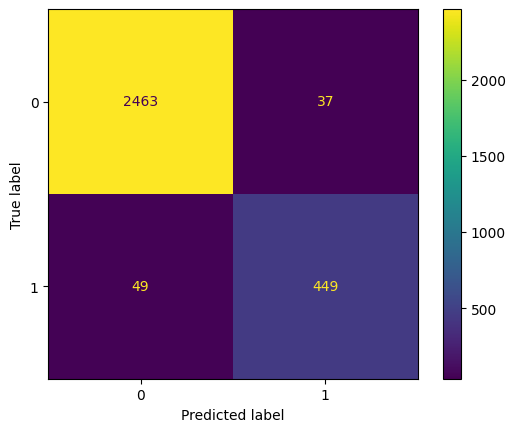

In [88]:
y_pred_xgb = xgb_model.predict(X_test)
cm_disp(y_test, y_pred_xgb, xgb_model)

In [95]:
features_weight = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)
features_weight

number_project               0.238582
tenure                       0.155648
overworked                   0.147083
last_evaluation              0.095138
average_monthly_hours        0.077892
high_perform_no_promotion    0.067338
work_accident                0.050927
salary                       0.038615
department_product_mng       0.015240
department_support           0.015064
department_accounting        0.013965
department_hr                0.012567
department_RandD             0.012154
department_technical         0.012112
promotion_last_5years        0.011955
department_sales             0.011282
department_marketing         0.009302
high_hours_low_evaluation    0.007749
department_management        0.007389
dtype: float32

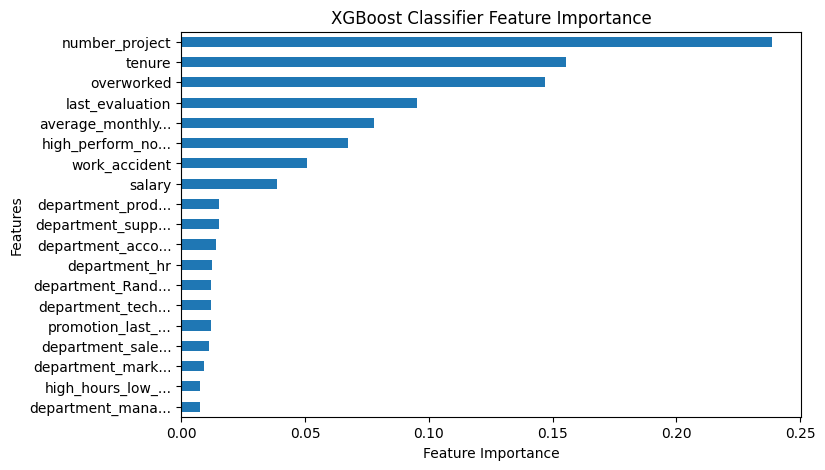

In [96]:
plt.figure(figsize=(8, 5))

features_weight = features_weight.sort_values(ascending=True)
features_weight.index = [col[:15] + '...' if len(col) > 15 else col for col in features_weight.index]
features_weight.plot.barh();

plt.title('XGBoost Classifier Feature Importance')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.show()

The XGBoost model performed very high scores too with 0.97 roc-auc score. This also means that this model is great in predicting whether or not an employee will leave the company. The feature importances for this model has different orders with the random forest but overall, they have the same top predictors especially the number one which is the number of projects.

## 5. Conclusion

### Results and Discussion

The dataset contains 14999 rows by which 3008 were duplicates but no null. Only the `tenure` feature have outliers for its data distribution for the continuous and discrete features. Our target variable `left` has a slight imbalance of 83% for the negative cases (employee staying) and 17% for the positive cases (employee leaving).

**Features engineered** are:
- `overworked` - determines if the employee spends average monthly hours greater than 225
- `high_perform_no_promotion` - if an employee works more than 225 hours/month, has a score for last evaluation of greater than 0.90 but received no promotions over the last 5 years
- `high_hours_low_evaluation` - if an employee works more than 250 hours/month but only have evaluation score of less than 0.85

**Clusters found**
A scatterplot of average_monthly_hours and satisfaction_level revealed three clusters of employee who left. These clusters are further studied and the groups have a common characteristics which define them:
1. Low performing employees with evaluation scores of only **0.48-0.54**, only have **2 projects** and **3 years** in the company.
2. Employees who are **5 years** in the company, work **237-262** hours/month, **4-5 projects**,high evaluation scores **0.87-0.98**, and fair satisfaction **0.77-0.87**.
3. High performing employees with **0.82-0.93** evaluation scores but overworked with **256-285 hours** monthly, **6-7 projects**, on their **4th year** in the company and feel a **very low satisfaction level of 0.10**.

Both the 2nd and 3rd group also have only one employee promotion out of approximately 400 each. Most of the employee who left belong to these groups where only 13% do not belong. 

For employees with **4-6 projects**, employees who **leave** are observed to have **worked more hours** than their peers who stayed. The higher number of working hours for the same number of project may have cause dissatisfaction when employees compared their work demands with their peers. A hypothesis test is conducted and confirmed that for 4-6 projects, the average monthly hours of those who left are significantly higher than those who stayed. All employees who have 7 or more projects left the company.

For employees in different salary brackets, it is observed that the percentage of those who leave are higher in low salary. It decreases as the salary bracket increases. A chi-square test of independence is conducted to test this hypothesis and it is found out that **employee leaving** indeed is **affected by salary bracket**.

No large differences between turnover ratio is observed per department. For work accident related, only 5.7% of those who had an accident left which is less than 18.6% of those who haven't experienced an accident. This is quite counter-intuitive and we need more data to study this, perhaps those who had an accident were compensated well which reduced the likelihood of them leaving. 

**Prediction Models**
**Logistic Regression**
The logistic regression classifier produced an auc score of **0.79** with precision at 0.58 and recall at 0.16. The precision and recall scores are not satisfactory. We can adjust threshold though to increase predictions of positive cases. There is no strong linear relationship when the discrete and continuous variables are plotted against the log-odds which might signify why the model doesn't fit well with the data. Also, logistic regression is not good with the class imbalance for the target variable.

**Random Forest Classifier**
Random forest classifier produced an auc score of **0.97** with precision at 0.95 and recall at 0.90. This means that the model predicts positive and negative cases well. The model is a good predictor of an employee leaving.

**XGBoost Classifier**
XGBoost classifer produced an auc score of **0.97** with precision at 0.92 and recall at 0.90. The model is great too in predicting employee leaving.

The most important features that is both in the top features of Random Forest and XGBoost models are number of projects, monthly hours, tenure, evaluation score with our engineered features overworked, and high performance and hours with no promotion.

### Conclusion and Recommendation

The EDA, model and feature importances results reveals that employees who leave are overworked. 

To retain employees, the following are recommended for the stakeholders:
- The two groups of employee who left that have high performance (high evaluation, high hours) and on their 4th-5th year must be given attention since the years of company knowledge and their high performance are huge asset loss
- The group of low performing employees on their 3rd year must be considered. Company can invest in upskilling of this individuals or conduct assemblies and ask how the company can help them boost their performance
- Number of projects and working hours must be capped
    - The optimal number of projects is between 3-5
    - Relative to the number of projects, it is important that working over the standard hours is not forced on the employee
    - Review company policies on overtime as it can be one of the reason of leaving if the employee is overworked and not well compensated
    - If projects and hours cannot be limited, ensure to compensate this well enough
- Consider promotions, better compensations on the group of high performing and experienced employee
- Almost half of those who leave are in the high performing and experienced group
    - This can be quite costly for promotions and compensations but maybe not too huge increases can keep these employees without hurting the company finances
    - Consider nonfinance compensations such as awards as it can boost employee morale